# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Grace Ketchum
* Username: gbketchum
* Student number: s6230024
* Group (AS1, etc.): AS1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

$$ g=\frac{4\pi^2 L}{T^2} $$
$$ \Delta{g}=\sqrt{\left(\left(\frac{\partial{g}}{\partial{L}}\right)\Delta{L}\right)^2+\left(\left(\frac{\partial{g}}{\partial{T}}\right)\Delta{T}\right)^2}$$
$$ \Delta{g}=\sqrt{\left(\left(\frac{4\pi^2}{T^2}\right)\Delta{L}\right)^2+\left(\left(\frac{-8\pi L}{T^3}\right)\Delta{T}\right)^2}$$
$$ g= 9.77\pm 0.22 m\cdot s^{-2} $$


In [3]:
import numpy as np
import math


L=1.00
T=2.01
dL=0.01
dT=0.02

pdL=(4*((math.pi)**2))/(T**2) #calculating the partial derivative of g with respect to L
pdT=(((-8)*(math.pi)**2)*L)/(T**3) #calculating the partial derivative of g with respect to T

g=(4*((math.pi)**2)*L)/(T**2) #the calculation for g with the given values
dg=((((pdL)*dL)**2)+(((pdT)*dT)**2))**(1/2) #the error of g using taylor expansion
print(f"The value of the derived g is {g:.2f}, and the error using partial derivatives is {dg:.2f}")

Ldist=np.random.normal(L, dL, 100000) #creating teh distribution of L
Tdist=np.random.normal(T, dT, 100000) #creating the distribution of T

g2=(4*((math.pi)**2)*Ldist)/(Tdist**2) #the calculation of g with the arrays
mu=np.mean(g2) #the value of g with this distribution
stdv=np.std(g2) #the error of g using monte carlo
print(f"The value of g calculated using monte carlo is {mu:.2f}, and its error usining monte carlo error propagation is {stdv:.2f}")

The value of the derived g is 9.77, and the error using partial derivatives is 0.22
The value of g calculated using monte carlo is 9.77, and its error usining monte carlo error propagation is 0.22


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
from math import sqrt
from IPython.display import display, Math

a=float(input("Input a value for a:"))
b=float(input("Input a value for b:"))
c=float(input("Input a value for c:"))

D= (b**2)-4*a*c #calculating the discriminant

if D>0:
    x1= (-b+(sqrt(D)))/(2*a) #first real sol
    x2= (-b-(sqrt(D)))/(2*a) #second real sol
    f01=a*(x1**2)+b*x1+c #calculation of f(x) for both solutions to verify if f(x)=0
    f02=a*(x2**2)+b*x2+c
    print(f"The equation gives f(x1)={f01:.2f}, f(x2)={f02:.2f}") #rounding to two decimal places
    print(f"The two solutions of the second degree polynomial are {x1} and {x2}")
elif D==0:
    x= -b/(2*a)
    f0=a*(x**2)+b*x+c #calculation of f(x) for the solution to verify if f(x)=0
    print(f"The equation gives f(x)={f0}")
    print(f"The single solution of the second degree polynomial is {x}")
else:
    x1 = (-b + sqrt(-D)*1j) / (2*a)
    x2 = (-b - sqrt(-D)*1j) / (2*a)
    f01=a*(x1**2)+b*x1+c #calculation of f(x) for both solutions to verify if f(x)=0
    f02=a*(x2**2)+b*x2+c
    print(f"The equation gives f(x1)={f01.real:.2f}{f01.imag:+.2f}j, f(x2)={f02.real:.2f}{f02.imag:+.2f}j")
    print(f"The two solutions of the second degree polynomial are {x1} and {x2}")


display(Math(rf"y=ax^2+bx+c")) #displaying teh equations
display(Math(rf"y={a}x^2+{b}x+{c}"))

Input a value for a: 1
Input a value for b: 1
Input a value for c: 1


The equation gives f(x1)=0.00+0.00j, f(x2)=0.00+0.00j
The two solutions of the second degree polynomial are (-0.5+0.8660254037844386j) and (-0.5-0.8660254037844386j)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

Enter a value for A: 1.0
Enter a value for x0: 0.0
Enter a value for sigma: 2.0
Enter a value for z0: 0.0
Enter a value for the lower integration limit: 0
Enter a value for the upper integration limit: 2.5


The area between x=0 and x=2.5 is equal to (1.9769788548675902, 2.1948874438710744e-14)
The area between x=-infinty and x=infinity is equal to (5.013256549262001, 6.333282282770592e-09)
The calculated area under the curve is 5.0132565492620005, which is equal to the are evaluated using quad()


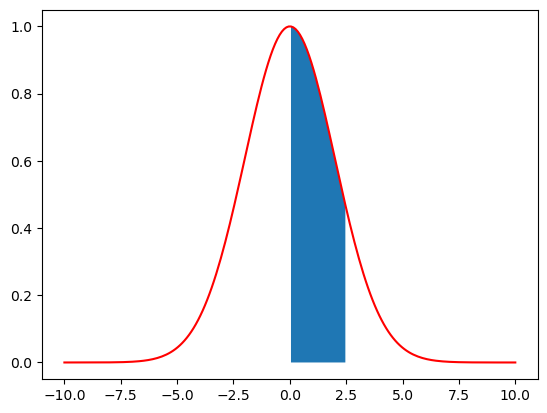

In [1]:
import numpy as np
import math
import scipy
import matplotlib.pyplot as plt
A = float(input("Enter a value for A:"))#1.0 #setting the initial conditions
x0 = float(input("Enter a value for x0:"))
sigma = float(input("Enter a value for sigma:"))
z0 = float(input("Enter a value for z0:"))
x=np.linspace(-10, 10, 200)

def gauss(x, A, x0, sigma, z0): #defining teh function
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

def gauss2(x): #making it so that x is teh only variable we use i the integration
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

a=float(input("Enter a value for the lower integration limit:"))
b=float(input("Enter a value for the upper integration limit:"))

intt=scipy.integrate.quad(gauss2, a, b) #integrating from 0 to 2.5
intt2=scipy.integrate.quad(gauss2, -np.inf, np.inf) #integrating from negative infinity to infinity 

x_values=x
y_values=gauss2(x)
where=(a<=x)&(x<=b) #making it so that the appropriate area can be filled in


print(f"The area between x=0 and x=2.5 is equal to {intt}")
print(f"The area between x=-infinty and x=infinity is equal to {intt2}")
plt.plot(x_values, y_values, color='r')
plt.fill_between(x_values[where], y_values[where])
plt.show


#part 2
area1=A*sigma*(2*math.pi)**(1/2) #using the formula
print(f"The calculated area under the curve is {area1}, which is equal to the are evaluated using quad()")

https://github.com/graceketchum648-collab/PROGNUM-repo.git

In Task 4

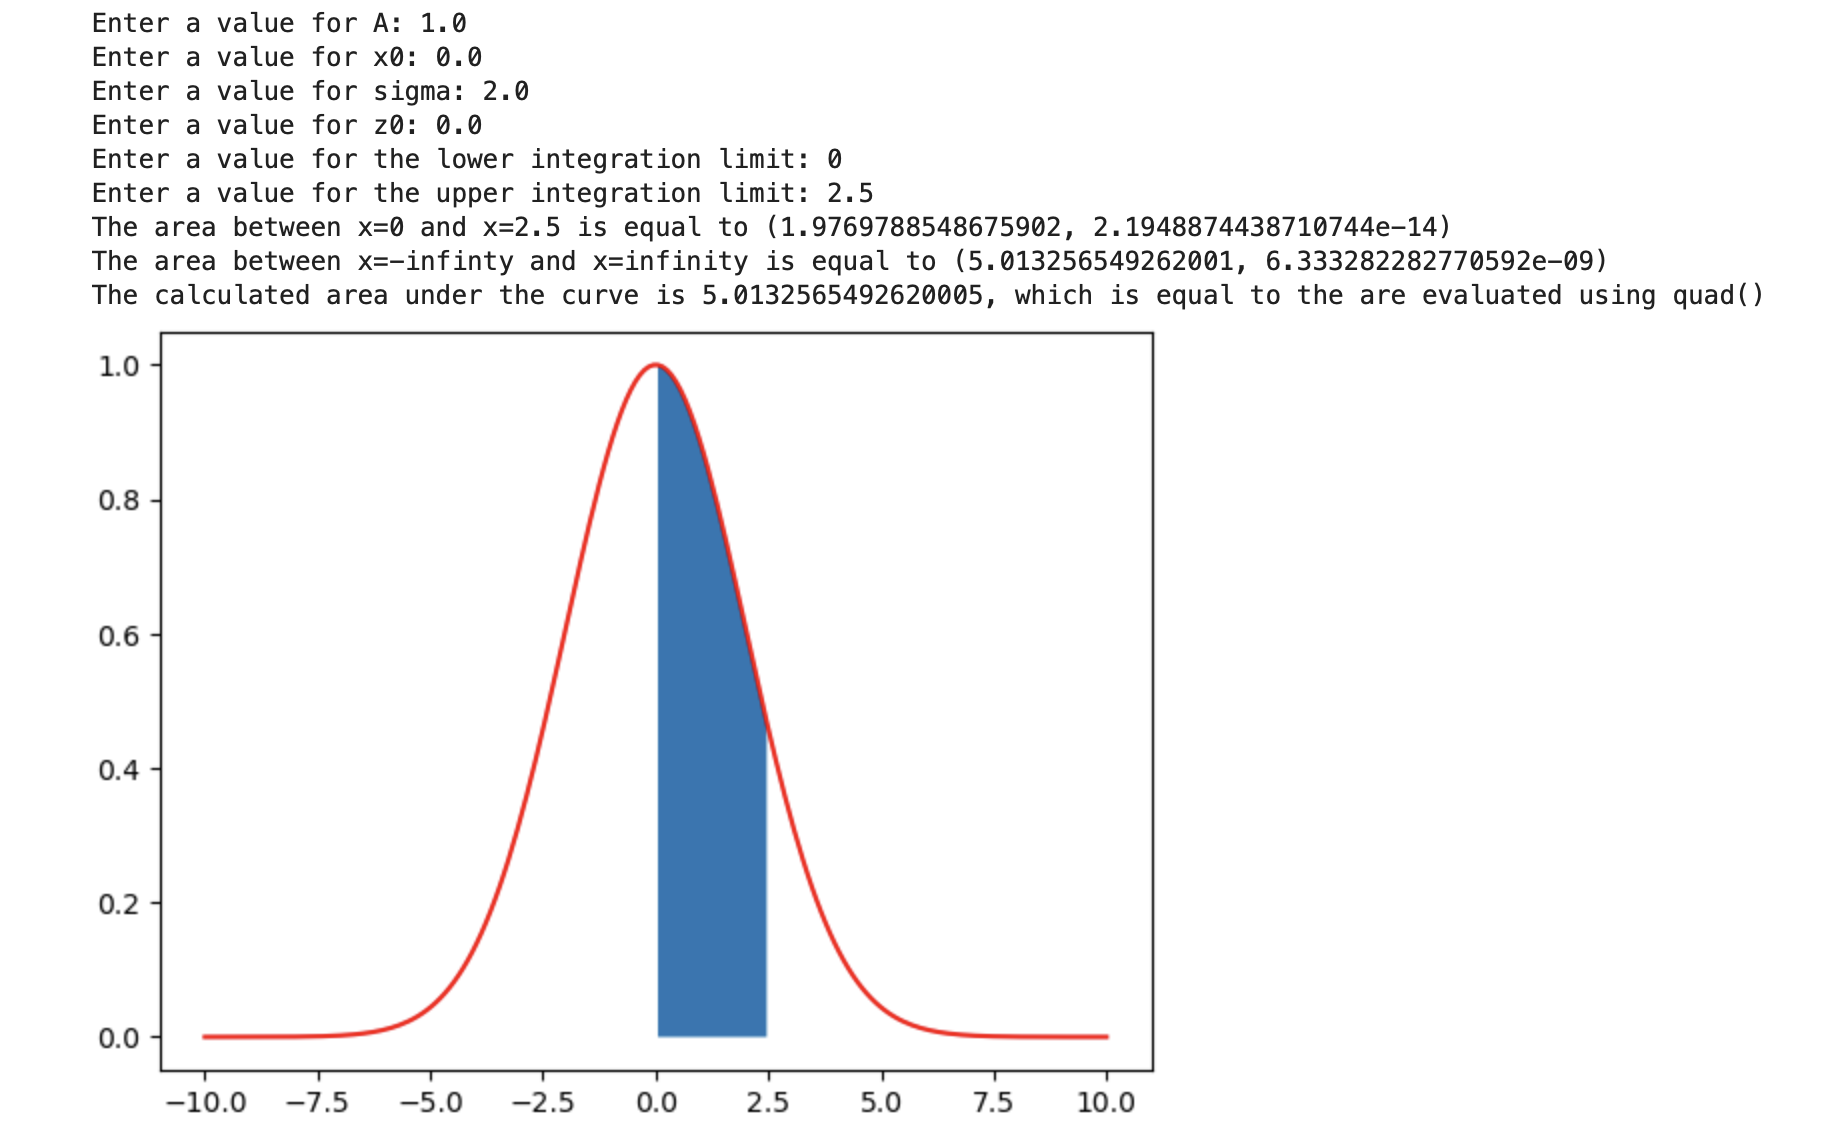

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 5

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

https://github.com/graceketchum648-collab/PROGNUM-repo.git

In Task 4

In [2]:
import numpy as np
from numpy import sin, cos, exp, pi
import math
import scipy

fofx = input("Input a function f(x) using python syntax: ")

try: #having a try except clause so that the bounds have to be numbers
    a = eval(input("Input a lower bound: "))
    b = eval(input("Input an upper bound: "))
except Exception:
    print("Oops! Your bounds did not use valid numbers, try again!")
    exit()

if a >= b: #so that the monte carlo integration expression can work
    print("Lower bound must be smaller than upper bound.")
    exit()

n=10000000 #number of data points (heightened)

x=np.random.uniform(a, b, n) #choosing x values from a random uniform distribution

try:
    f = lambda x: eval(fofx) #making it so that fofx is evaluated with x as the variable
    f(1)   # test evaluation
except Exception:
    print("Oops! You need to use valid python syntax for your function. Try again...")
    exit()

intt = scipy.integrate.quad(f, a, b) #using quad to integrate

y = eval(fofx)
inttmc=((b-a)/n)*np.sum(y) #using the monte carlo expression to integrate

print(intt)
print(inttmc)

Input a function f(x) using python syntax:  (x**4)+exp(sin(x)+cos(x))
Input a lower bound:  0
Input an upper bound:  pi


(68.72932272689113, 8.854230135489868e-10)
68.70231495490698


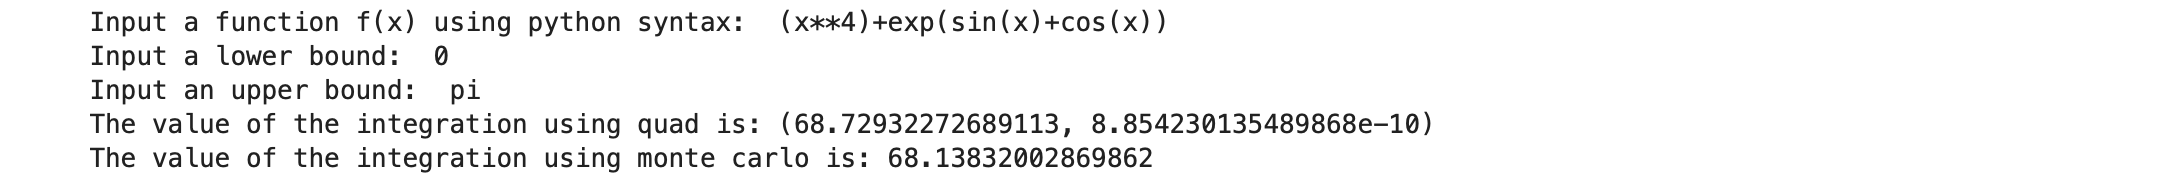

In [9]:
from sympy.abc import x
import sympy

s = "(x**4)+exp(sin(x)+cos(x))"
expr = sympy.sympify(s)
intg = sympy.N(sympy.integrate(expr, (x, 0.0, sympy.pi)))
print(f"Integral of {s}: {intg}")

Integral of (x**4)+exp(sin(x)+cos(x)): 68.7293227268911


In [10]:
# Leave unaltered
totalpoints += 6
currentpoints += 5.5

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

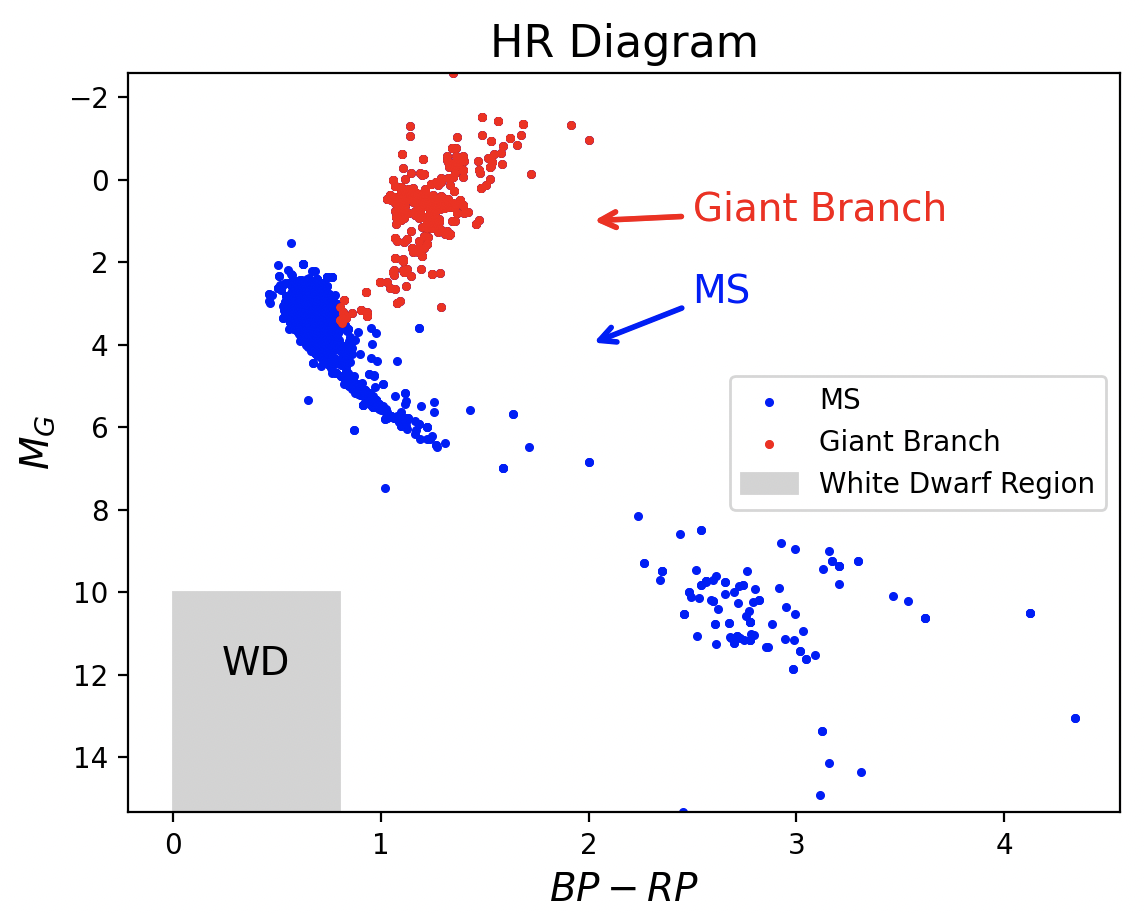

(np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.float32(nan), np.int64(133), np.int64(0), np.float32(418.9276))
[   0 3072    0 ... 2052    0  516]
[       0     3072        0      512        0        0        0        0
 50331652     1536]
[       0 50331652        0     2048        0  2097152     3072     2052
        0      516]


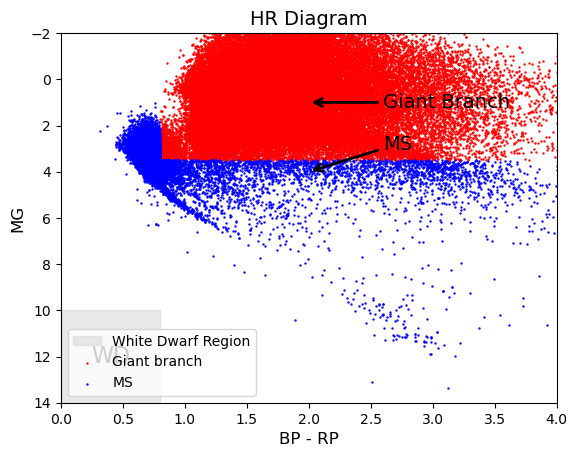

In [6]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names



mask1 = ((data['STARFLAG'] == 0) & #creating a mask to filter the data
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])))

clean_data = data[mask1]

n = len(clean_data)
indices = np.random.choice(n, int(0.8 * n), replace=False)
data_80 = clean_data[indices]

para=data_80['GAIAEDR3_PARALLAX']
mg=data_80['GAIAEDR3_PHOT_G_MEAN_MAG']
Mg=mg+(5*np.log10(para/1000))+5 #converting into absolute mag

x= data_80['GAIAEDR3_PHOT_BP_MEAN_MAG']-data_80['GAIAEDR3_PHOT_RP_MEAN_MAG']

mask2= ((x>0.8)&(Mg<3.5))

print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"


plt.annotate('MS', #making the arrows match teh original diagram
             xy=(2.0, 4.0),#point on the same position
             xytext=(2.6, 2.8),#text pos
             fontsize=14,        
             color='black',
             va='center',         
             ha='left',
             arrowprops=dict(
                 arrowstyle="->",
                 color='black', 
                 lw=2,             ))

plt.annotate("Giant Branch",
             xy=(2.0, 1.0), 
             xytext=(2.6, 1.0),       
             fontsize=14, 
             color='black',     
             va='center', 
             ha='left', 
             arrowprops=dict(
                 arrowstyle="->", 
                 color='black', 
                 lw=2,
             ))



xwd= np.linspace(0, 0.8, 10) #x values for white drawvesmatching the requirements 

plt.fill_between(xwd, 10, 16, # y1=10 is the top boundary (faintest limit)
                 color='lightgray', # y2=16 is the bottom boundary
                 alpha=0.5, 
                 label='White Dwarf Region')



plt.scatter(x[mask2], Mg[mask2], color='r', label='Giant branch', s=0.5)
plt.scatter(x[~mask2], Mg[~mask2], color='b', label='MS', s=0.5)
plt.text(0.4, 12, 'WD', fontsize=16, ha='center', va='center')
plt.xlim(0, 4)
plt.ylim(14, -2)
plt.legend()
plt.xlabel('BP - RP', fontsize= 12)
plt.ylabel('MG', fontsize=12)
plt.title('HR Diagram', fontsize=14)
plt.show()

In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 5.5

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [13]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 24.0.  Task Grade = 9.2
